In [1]:
import pandas as pd

from src.real_world.preprocess_real import prepare_real_dataset
from src.real_world.train_lr_real import train_lr_real, evaluate_lr_real

from src.metrics.evaluation import evaluate_model  # fairness_eval.py
from src.metrics.visualize_fairness import plot_equal_opportunity  # EO plot


In [2]:
df = pd.read_csv("diabetes_dataset.csv")
data = prepare_real_dataset(df)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
sens_test = data["sens_test"]


In [3]:
lr_model = train_lr_real(X_train, y_train)


In [4]:
results_lr = evaluate_lr_real(lr_model, X_test, y_test)
y_pred_lr = results_lr["y_pred"]

print("LR Accuracy:", results_lr["accuracy"])


LR Accuracy: 0.9606934489081513


In [5]:
fair_results_lr = evaluate_model(y_test.values, y_pred_lr, sens_test)

print(fair_results_lr)


{'accuracy': 0.9606934489081513, 'precision': 0.8776859504132232, 'recall': 0.6247058823529412, 'gender_tprs': {'Female': 0.6254796623177283, 'Male': 0.623897353648757}, 'gender_gap': 0.001582308668971355, 'race_tprs': {'AfricanAmerican': 0.6288288288288288, 'Asian': 0.6090373280943026, 'Other': 0.6344086021505376, 'Caucasian': 0.625, 'Hispanic': 0.626746506986028}, 'race_gap': 0.02537127405623507}


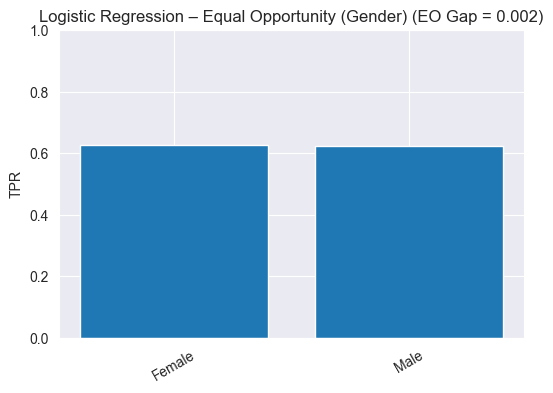

In [6]:
plot_equal_opportunity(
    fair_results_lr["gender_tprs"],
    title="Logistic Regression – Equal Opportunity (Gender)"
)


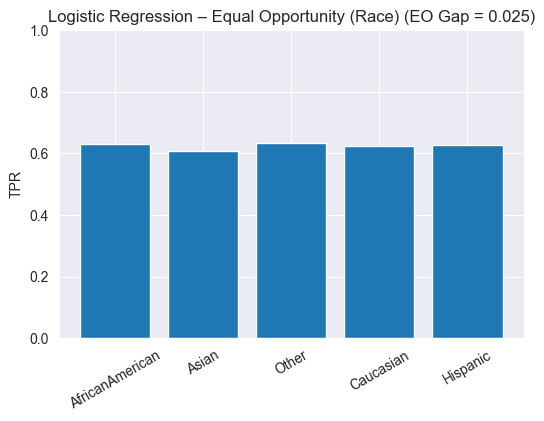

In [7]:
plot_equal_opportunity(
    fair_results_lr["race_tprs"],
    title="Logistic Regression – Equal Opportunity (Race)"
)
